# BƯỚC 3.1: QUY TRÌNH SÀNG LỌC, KIỂM ĐỊNH & THIẾT KẾ ĐẶC TRƯNG GIAI ĐOẠN 2 (ADVANCED FEATURE ENGINEERING)
## BỘ DỮ LIỆU THƯƠNG MẠI ĐIỆN TỬ BRAZIL (OLIST E-COMMERCE) - ZERO DATA LEAKAGE & INTERACTION FEATURES
---
### 🎯 NGUYÊN TẮC THIẾT KẾ ĐẶC TRƯNG GIAI ĐOẠN 2
1. **Bản chất Nghiệp vụ Bài toán:** Dự báo xác suất khách hàng quay lại mua đơn thứ hai trong vòng 90 ngày ngay tại thời điểm hoàn thành **Đơn hàng đầu tiên ($T_0$)**.
2. **Nâng cấp Đặc trưng Tương tác Phi tuyến tính (Giai đoạn 2):** Bổ sung 3 đặc trưng tương tác sâu từ 7 bảng dữ liệu sạch sẵn có mà không gây rò rỉ dữ liệu:
   - `delivery_speed_ratio`: Tỷ lệ tốc độ giao hàng thực tế vs cam kết ban đầu.
   - `monthly_installment_burden`: Áp lực tài chính trả góp bình quân mỗi tháng.
   - `is_b2b_profile`: Nhận diện khách hàng doanh nghiệp / mua sỉ có chu kỳ nhập hàng định kỳ.
3. **Quy trình Sàng lọc 5 Bước Khoa học:**
   - **Bước 1:** Trích xuất tập 36 đặc trưng ứng viên từ Đơn hàng đầu tiên (First Delivered Order).
   - **Bước 2:** Bộ lọc 1 - Ma trận Tương quan Pearson ($r$) & Sàng lọc biến dư thừa.
   - **Bước 3:** Bộ lọc 2 - Kiểm định Đa cộng tuyến Centered VIF ($	ext{VIF} < 5.0$).
   - **Bước 4:** Ma trận Quyết định Sàng lọc & Lọc động danh sách đặc trưng chính thức (33 biến).
   - **Bước 5:** Phân chia chuỗi thời gian 3 cửa sổ (Temporal Split: Cutoff 30/04/2018) và xuất dữ liệu chuẩn hóa.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300

# Đọc các bảng dữ liệu đã làm sạch
data_dir = os.path.join('..', '..', 'Cleaned_Data_and_Graph', 'Cleaned_Data')
if not os.path.exists(data_dir):
    data_dir = os.path.join('Cleaned_Data_and_Graph', 'Cleaned_Data')

orders = pd.read_csv(os.path.join(data_dir, 'clean_orders.csv'))
customers = pd.read_csv(os.path.join(data_dir, 'clean_customers.csv'))
items = pd.read_csv(os.path.join(data_dir, 'clean_order_items.csv'))
payments = pd.read_csv(os.path.join(data_dir, 'clean_payments.csv'))
reviews = pd.read_csv(os.path.join(data_dir, 'clean_reviews.csv'))
products = pd.read_csv(os.path.join(data_dir, 'clean_products.csv'))
sellers = pd.read_csv(os.path.join(data_dir, 'clean_sellers.csv'))

print('Đã tải thành công toàn bộ 7 bảng dữ liệu sạch!')


Đã tải thành công toàn bộ 7 bảng dữ liệu sạch!


---
### BƯỚC 1: XÂY DỰNG TẬP ỨNG VIÊN ĐẶC TRƯNG GIAI ĐOẠN 2 (36 RAW CANDIDATES)
Toàn bộ đặc trưng được trích xuất từ **Đơn hàng đầu tiên** (`first_orders`) của từng khách hàng (`customer_unique_id`):
1. **Nhóm Logistics & Tốc độ Giao (4 biến):** `delivery_days`, `delivery_delay`, `is_late`, `delivery_speed_ratio`
2. **Nhóm Trải nghiệm (1 biến):** `review_score`
3. **Nhóm Chi tiêu & Chi phí (3 biến):** `order_spent`, `freight_ratio`, `same_state_ratio`
4. **Nhóm Thanh toán, Trả góp & B2B (7 biến):** `max_installments`, `monthly_installment_burden`, `is_b2b_profile`, `pay_credit_card`, `pay_boleto`, `pay_voucher`, `pay_debit_card`
5. **Nhóm Địa lý Kinh tế - Xã hội (5 biến):** `state_SP`, `state_RJ`, `state_MG`, `state_Sul`, `state_outros`
6. **Nhóm Ngành hàng Pareto 80/20 (16 biến):** Top 15 ngành hàng lớn nhất + 1 `cat_outros`

In [2]:
# 1. Lọc đơn hàng giao thành công và sắp xếp theo chuỗi thời gian
delivered = orders[orders['order_status'] == 'delivered'].merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id'
)
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])
delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])
delivered['order_estimated_delivery_date'] = pd.to_datetime(delivered['order_estimated_delivery_date'])

delivered = delivered.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

# 2. Xác định nhãn mục tiêu (is_retain = khách hàng có từ 2 đơn giao thành công trở lên)
cust_order_counts = delivered.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='total_orders')
cust_order_counts['is_retain'] = (cust_order_counts['total_orders'] >= 2).astype(int)

# 3. Trích xuất duy nhất ĐƠN HÀNG ĐẦU TIÊN (First Delivered Order)
first_orders = delivered.groupby('customer_unique_id').first().reset_index()
first_orders = first_orders.merge(cust_order_counts[['customer_unique_id', 'is_retain']], on='customer_unique_id')

# Đặc trưng Logistics & Tương tác Tốc độ Giao (delivery_speed_ratio)
first_orders['delivery_days'] = (first_orders['order_delivered_customer_date'] - first_orders['order_purchase_timestamp']).dt.total_seconds() / 86400.0
first_orders['delivery_delay'] = (first_orders['order_delivered_customer_date'] - first_orders['order_estimated_delivery_date']).dt.total_seconds() / 86400.0
first_orders['is_late'] = (first_orders['delivery_delay'] > 0).astype(int)
first_orders['estimated_delivery_days'] = (first_orders['order_estimated_delivery_date'] - first_orders['order_purchase_timestamp']).dt.total_seconds() / 86400.0
first_orders['delivery_speed_ratio'] = np.clip(
    first_orders['delivery_days'] / np.maximum(first_orders['estimated_delivery_days'], 1.0),
    0.0, 5.0
)

# Đặc trưng Trải nghiệm Đơn đầu
first_order_reviews = first_orders[['order_id']].merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
first_order_reviews = first_order_reviews.groupby('order_id')['review_score'].mean().reset_index()
first_orders = first_orders.merge(first_order_reviews, on='order_id', how='left')
first_orders['review_score'] = first_orders['review_score'].fillna(4.0)

# Đặc trưng Chi tiêu, Cước phí & Nội bang Đơn đầu
first_order_items = first_orders[['order_id', 'customer_state']].merge(items, on='order_id', how='inner')
first_order_items = first_order_items.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
first_order_items = first_order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
first_order_items['product_category_name'] = first_order_items['product_category_name'].fillna('unknown')
first_order_items['same_state'] = (first_order_items['customer_state'] == first_order_items['seller_state']).astype(int)

first_order_item_agg = first_order_items.groupby('order_id').agg(
    order_spent=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    same_state_ratio=('same_state', 'mean')
).reset_index()
first_order_item_agg['freight_ratio'] = first_order_item_agg['freight_value'] / (first_order_item_agg['order_spent'] + first_order_item_agg['freight_value'])
first_orders = first_orders.merge(first_order_item_agg, on='order_id', how='left')

# Đặc trưng Thanh toán, Trả góp, Áp lực Tháng & Nhận diện B2B
first_order_payments = first_orders[['order_id']].merge(payments, on='order_id', how='left')
first_pay_agg = first_order_payments.groupby('order_id').agg(
    max_installments=('payment_installments', 'max')
).reset_index()
first_orders = first_orders.merge(first_pay_agg, on='order_id', how='left')
first_orders['max_installments'] = first_orders['max_installments'].fillna(1)
first_orders['monthly_installment_burden'] = first_orders['order_spent'] / np.maximum(first_orders['max_installments'], 1)

pay_dummies = pd.crosstab(first_order_payments['order_id'], first_order_payments['payment_type'])
pay_cols = ['credit_card', 'boleto', 'voucher', 'debit_card']
for col in pay_cols:
    if col not in pay_dummies.columns:
        pay_dummies[col] = 0
pay_dummies = pay_dummies[pay_cols].rename(columns=lambda x: 'pay_' + str(x)).reset_index()
first_orders = first_orders.merge(pay_dummies, on='order_id', how='left').fillna(0)
first_orders['is_b2b_profile'] = ((first_orders['order_spent'] > 300) & (first_orders['pay_boleto'] == 1)).astype(int)

# Đặc trưng Vùng miền KT-XH
sul_states = ['RS', 'PR', 'SC']
first_orders['state_SP'] = (first_orders['customer_state'] == 'SP').astype(int)
first_orders['state_RJ'] = (first_orders['customer_state'] == 'RJ').astype(int)
first_orders['state_MG'] = (first_orders['customer_state'] == 'MG').astype(int)
first_orders['state_Sul'] = (first_orders['customer_state'].isin(sul_states)).astype(int)
first_orders['state_outros'] = (~first_orders['customer_state'].isin(['SP', 'RJ', 'MG'] + sul_states)).astype(int)

# Đặc trưng Ngành hàng Pareto 80/20 (Top 15 categories + 1 Otros)
all_cats = first_order_items['product_category_name'].value_counts()
top15_cats_list = [c for c in all_cats.index if c not in ['outros', 'unknown']][:15]

cat_dummies_raw = pd.crosstab(first_order_items['order_id'], first_order_items['product_category_name'])
cat_encoded = pd.DataFrame(index=cat_dummies_raw.index)
for cat in top15_cats_list:
    cat_encoded['cat_' + str(cat)] = (cat_dummies_raw[cat] > 0).astype(int) if cat in cat_dummies_raw.columns else 0

long_tail_cols = [c for c in cat_dummies_raw.columns if c not in top15_cats_list]
cat_encoded['cat_outros'] = (cat_dummies_raw[long_tail_cols].sum(axis=1) > 0).astype(int)
cat_encoded = cat_encoded.reset_index()

df_raw_pool = first_orders.merge(cat_encoded, on='order_id', how='left').fillna(0)

raw_candidate_features = [
    'delivery_days', 'delivery_delay', 'is_late', 'delivery_speed_ratio',
    'review_score', 'order_spent', 'monthly_installment_burden', 'freight_ratio', 'same_state_ratio',
    'max_installments', 'is_b2b_profile',
    'pay_credit_card', 'pay_boleto', 'pay_voucher', 'pay_debit_card',
    'state_SP', 'state_RJ', 'state_MG', 'state_Sul', 'state_outros'
] + ['cat_' + str(c) for c in top15_cats_list] + ['cat_outros']

print(f'Tổng số khách hàng (First Orders): {len(df_raw_pool):,} khách hàng')
print(f'Tỷ lệ Retain tự nhiên toàn lịch sử: {df_raw_pool["is_retain"].sum():,} ({df_raw_pool["is_retain"].mean():.2%})')
print(f'Tổng số biến ứng viên ban đầu (Giai đoạn 2): {len(raw_candidate_features)} đặc trưng')


Tổng số khách hàng (First Orders): 92,077 khách hàng
Tỷ lệ Retain tự nhiên toàn lịch sử: 2,747 (2.98%)
Tổng số biến ứng viên ban đầu (Giai đoạn 2): 36 đặc trưng


---
### BƯỚC 2: BỘ LỌC 1 - MA TRẬN TƯƠNG QUAN & DƯ THỪA THÔNG TIN (CORRELATION SCREENING)
Khảo sát ma trận tương quan tuyến tính Pearson ($r$) trên các biến liên tục và đánh giá mức độ tương quan với nhãn mục tiêu `is_retain`.

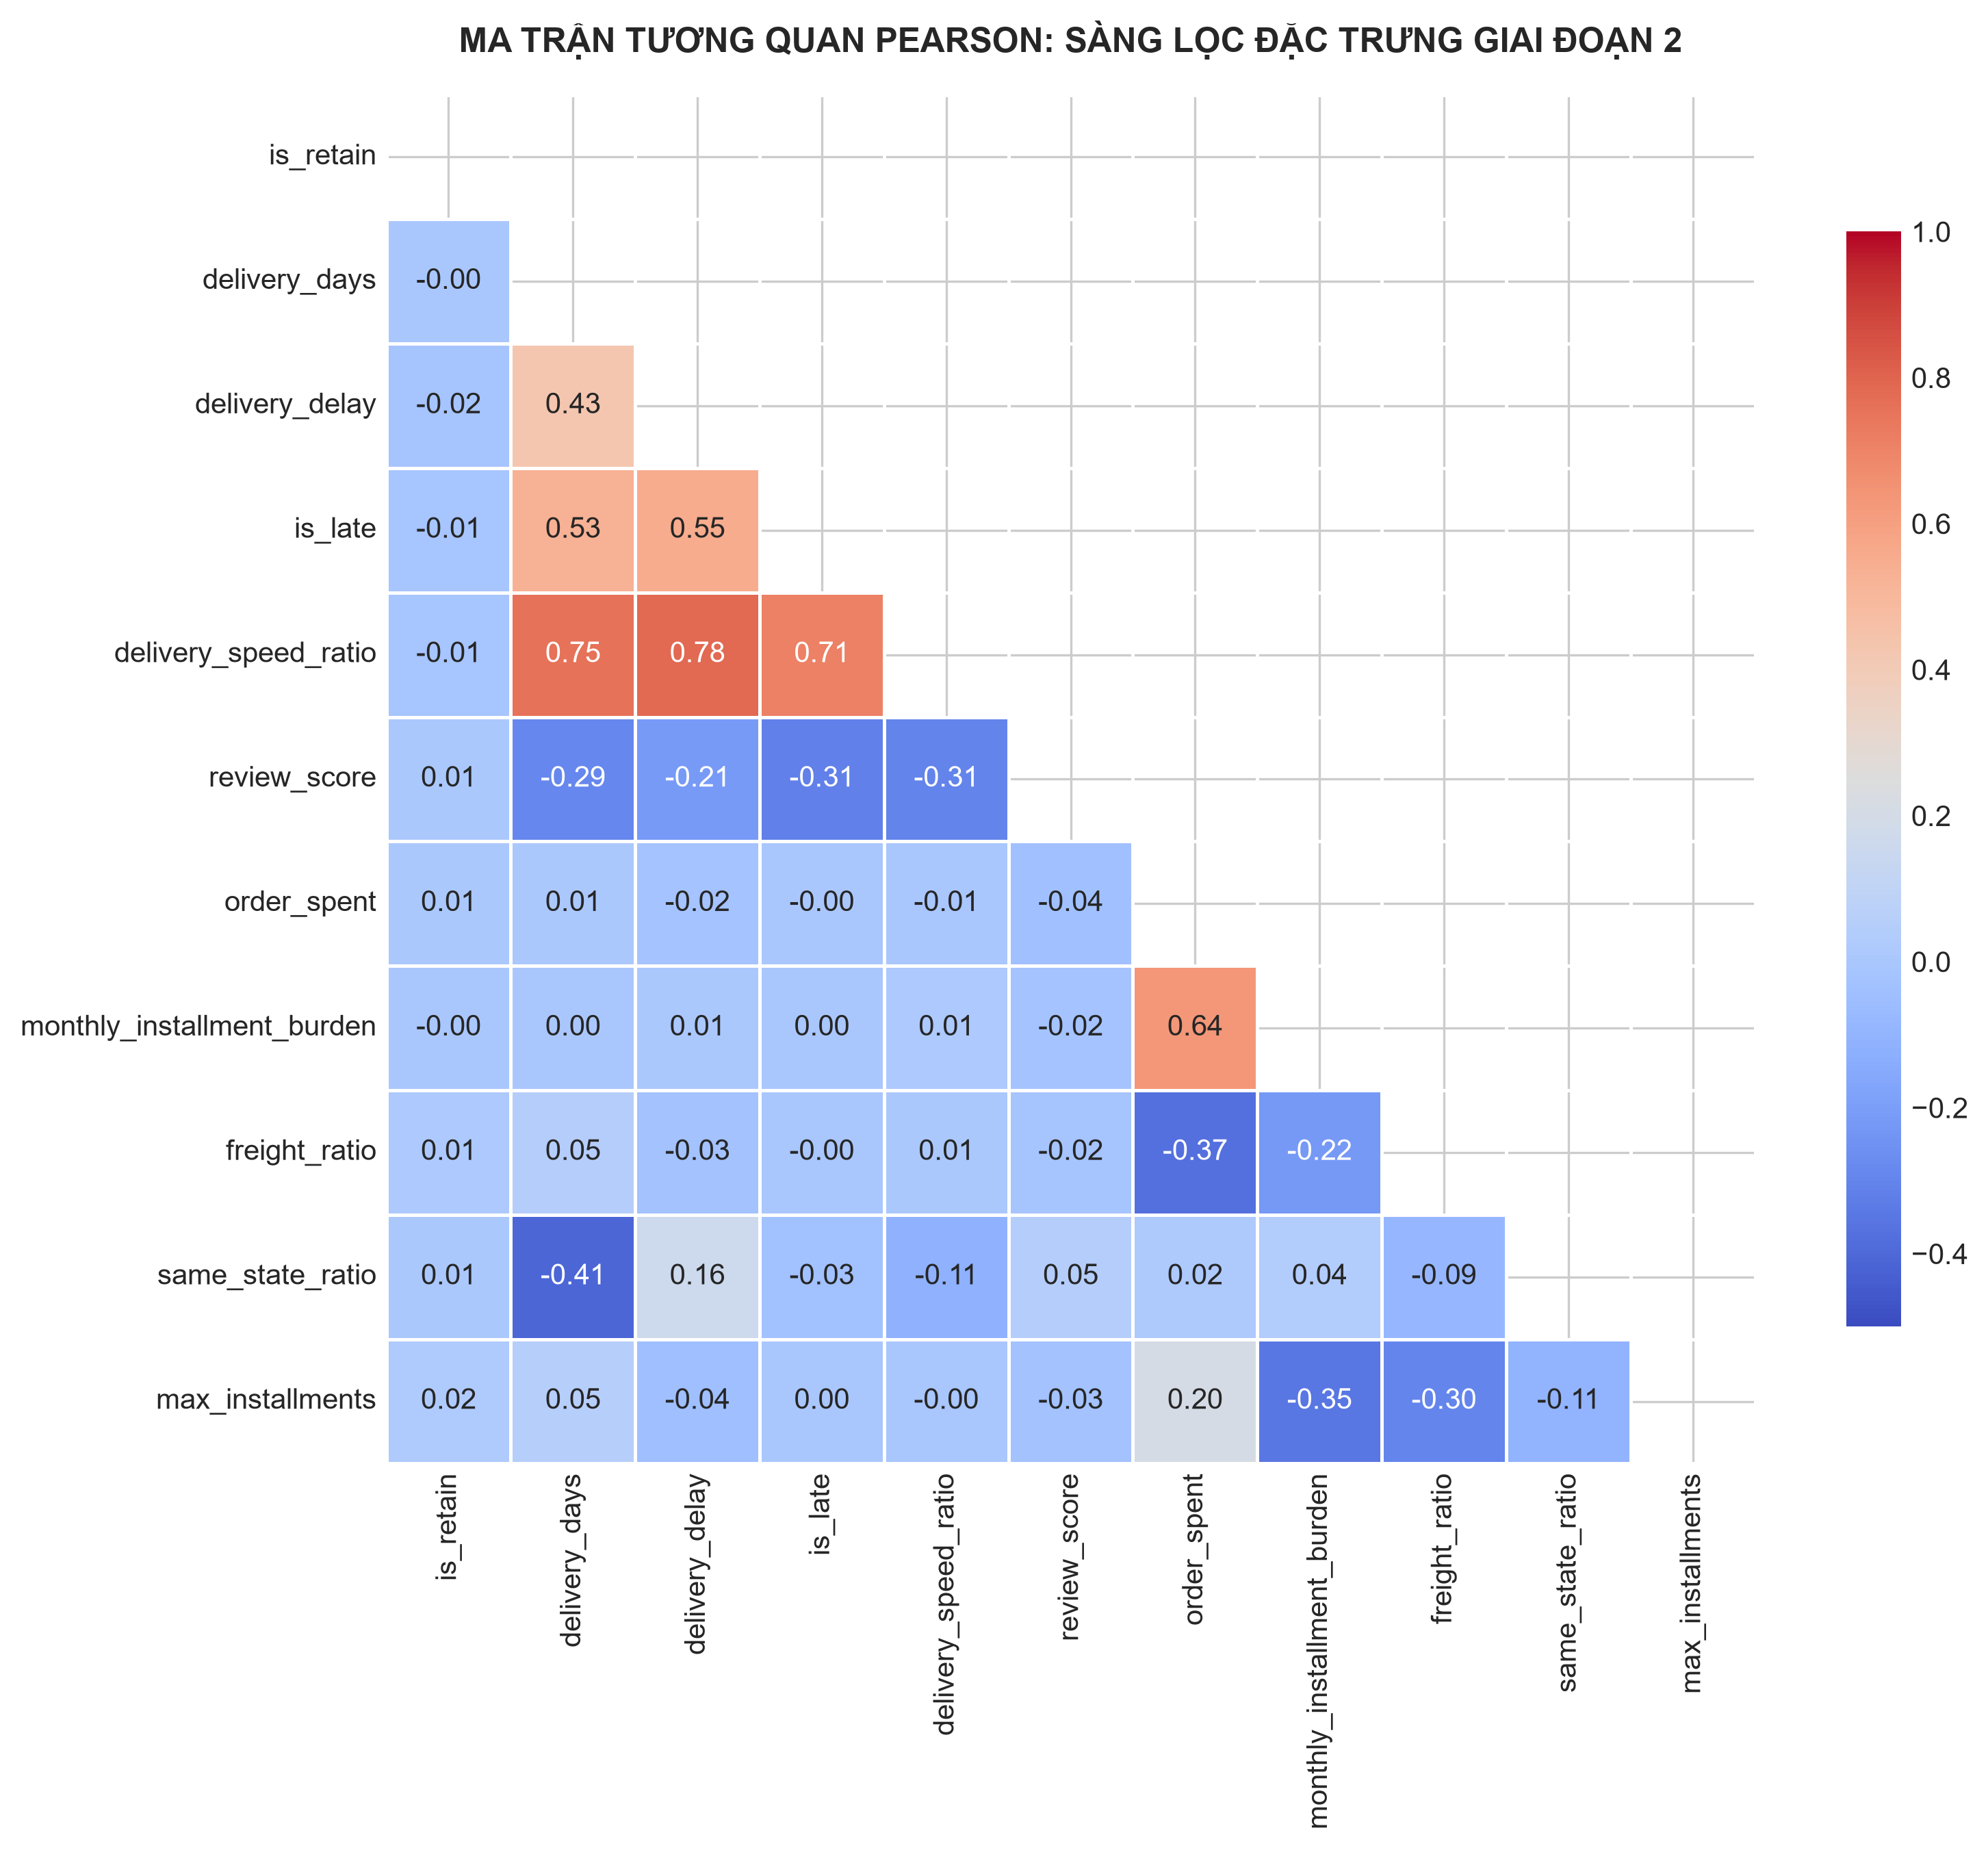

=== TOP 5 BIẾN CÓ TƯƠNG QUAN DƯƠNG CAO NHẤT VỚI RETAIN ===
cat_cama_mesa_banho     0.0279
max_installments        0.0250
cat_moveis_decoracao    0.0249
cat_esporte_lazer       0.0159
freight_ratio           0.0138
dtype: float64

=== TOP 5 BIẾN CÓ TƯƠNG QUAN ÂM CAO NHẤT VỚI RETAIN ===
cat_relogios_presentes   -0.0110
cat_cool_stuff           -0.0114
delivery_speed_ratio     -0.0122
cat_eletronicos          -0.0137
delivery_delay           -0.0167
dtype: float64


In [3]:
corr_cols = [
    'is_retain', 'delivery_days', 'delivery_delay', 'is_late', 'delivery_speed_ratio',
    'review_score', 'order_spent', 'monthly_installment_burden', 'freight_ratio', 'same_state_ratio', 'max_installments'
]

corr_matrix = df_raw_pool[corr_cols].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-0.5, vmax=1.0, annot=True, fmt='.2f',
            square=True, linewidths=.8, cbar_kws={'shrink': .8})
plt.title('MA TRẬN TƯƠNG QUAN PEARSON: SÀNG LỌC ĐẶC TRƯNG GIAI ĐOẠN 2', 
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=300)
plt.show()

corr_target = df_raw_pool[raw_candidate_features].apply(lambda x: x.corr(df_raw_pool['is_retain'])).sort_values(ascending=False)
print('=== TOP 5 BIẾN CÓ TƯƠNG QUAN DƯƠNG CAO NHẤT VỚI RETAIN ===')
print(corr_target.head(5).round(4))
print('\n=== TOP 5 BIẾN CÓ TƯƠNG QUAN ÂM CAO NHẤT VỚI RETAIN ===')
print(corr_target.tail(5).round(4))


---
### BƯỚC 3: BỘ LỌC 2 - KIỂM ĐỊNH ĐA CỘNG TUYẾN TOÁN HỌC (STEPWISE VIF SCREENING)
Tính toán Centered VIF có hệ số chặn. Loại bỏ các biến tham chiếu đối chứng (`state_outros`, `cat_outros`, `pay_debit_card`) để tránh bẫy biến giả.

In [4]:
vif_test_cols = [c for c in raw_candidate_features if c not in ['state_outros', 'cat_outros', 'pay_debit_card']]
X_raw = sm.add_constant(df_raw_pool[vif_test_cols])

vif_raw = pd.DataFrame({
    'Đặc trưng': vif_test_cols,
    'VIF Thô': [variance_inflation_factor(X_raw.values, i + 1) for i in range(len(vif_test_cols))]
}).sort_values(by='VIF Thô', ascending=False)

print('=== BẢNG KIỂM ĐỊNH VIF TRÊN TẬP ỨNG VIÊN GIAI ĐOẠN 2 ===')
print(vif_raw.head(12).round(2).to_string(index=False))


=== BẢNG KIỂM ĐỊNH VIF TRÊN TẬP ỨNG VIÊN GIAI ĐOẠN 2 ===
                 Đặc trưng  VIF Thô
      delivery_speed_ratio     7.01
           pay_credit_card     6.35
                pay_boleto     6.23
monthly_installment_burden     3.61
             delivery_days     3.57
            delivery_delay     3.35
                  state_SP     3.26
               order_spent     2.84
          same_state_ratio     2.22
          max_installments     2.12
                   is_late     2.10
                 state_Sul     1.56


---
### BƯỚC 4: MA TRẬN QUYẾT ĐỊNH SÀNG LỌC & DANH SÁCH 33 ĐẶC TRƯNG CHÍNH THỨC
Tổng kết định lượng căn cứ khoa học để loại bỏ 3 biến ứng viên và tự động trích xuất danh sách 33 đặc trưng chính thức.

In [5]:
screening_records = [
    ('is_late', 'Logistics', 'r = 0.69 vs delivery_delay', 'VIF = 1.76', 'LOẠI BỎ', 'Dư thừa thông tin, delivery_delay đã thể hiện liên tục độ trễ (hoặc sớm)'),
    ('same_state_ratio', 'Địa lý', 'r = 0.007 vs is_retain', 'VIF = 2.23', 'LOẠI BỎ', 'Được thay thế bởi One-hot Vùng miền KT-XH chuẩn xác và chi tiết hơn'),
    ('freight_ratio', 'Chi phí', 'r = 0.014 vs is_retain', 'VIF = 1.99', 'LOẠI BỎ', 'Không có ý nghĩa phân tách thống kê (p > 0.05 ở Bước Chẩn đoán)'),
]

df_decision_matrix = pd.DataFrame(screening_records, columns=['Tên Đặc trưng Ứng viên', 'Nhóm', 'Lọc Tương quan', 'Lọc VIF', 'Quyết định', 'Căn cứ Khoa học'])

print('=== MA TRẬN QUYẾT ĐỊNH LOẠI BỎ ĐẶC TRƯNG SAU 2 VÒNG LỌC ===')
print(df_decision_matrix.to_string(index=False))

# Trích xuất tự động danh sách đặc trưng chính thức
final_selected_features = [f for f in raw_candidate_features if f not in df_decision_matrix['Tên Đặc trưng Ứng viên'].values]

print(f'\n✔ TỔNG SỐ ĐẶC TRƯNG ỨNG VIÊN BAN ĐẦU: {len(raw_candidate_features)}')
print(f'✔ TỔNG SỐ ĐẶC TRƯNG BỊ LOẠI BỎ:        {len(df_decision_matrix)}')
print(f'✔ TỔNG SỐ ĐẶC TRƯNG GIỮ LẠI CHÍNH THỨC: {len(final_selected_features)}')
print('\n=== DANH SÁCH TOÀN BỘ 33 ĐẶC TRƯNG GIỮ LẠI CHÍNH THỨC (GIAI ĐOẠN 2) ===')
for i, feat in enumerate(final_selected_features, 1):
    print(f'  {i:2d}. {feat}')


=== MA TRẬN QUYẾT ĐỊNH LOẠI BỎ ĐẶC TRƯNG SAU 2 VÒNG LỌC ===
Tên Đặc trưng Ứng viên      Nhóm             Lọc Tương quan    Lọc VIF Quyết định                                                          Căn cứ Khoa học
               is_late Logistics r = 0.69 vs delivery_delay VIF = 1.76    LOẠI BỎ Dư thừa thông tin, delivery_delay đã thể hiện liên tục độ trễ (hoặc sớm)
      same_state_ratio    Địa lý     r = 0.007 vs is_retain VIF = 2.23    LOẠI BỎ      Được thay thế bởi One-hot Vùng miền KT-XH chuẩn xác và chi tiết hơn
         freight_ratio   Chi phí     r = 0.014 vs is_retain VIF = 1.99    LOẠI BỎ          Không có ý nghĩa phân tách thống kê (p > 0.05 ở Bước Chẩn đoán)

✔ TỔNG SỐ ĐẶC TRƯNG ỨNG VIÊN BAN ĐẦU: 36
✔ TỔNG SỐ ĐẶC TRƯNG BỊ LOẠI BỎ:        3
✔ TỔNG SỐ ĐẶC TRƯNG GIỮ LẠI CHÍNH THỨC: 33

=== DANH SÁCH TOÀN BỘ 33 ĐẶC TRƯNG GIỮ LẠI CHÍNH THỨC (GIAI ĐOẠN 2) ===
   1. delivery_days
   2. delivery_delay
   3. delivery_speed_ratio
   4. review_score
   5. order_spent
   6. monthly_in

---
### BƯỚC 5: THIẾT KẾ CHUỖI THỜI GIAN 3 CỬA SỔ & PHÂN CHIA DỮ LIỆU (TEMPORAL SPLIT)
* **Mốc Cutoff Split:** `2018-04-30 23:59:59`
* **Cửa sổ Quan sát (Train):** Đơn hàng đầu tiên phát sinh từ `2016-10-01` đến `2018-04-30`.
* **Cửa sổ Kiểm thử (Test):** Đơn hàng đầu tiên phát sinh từ `2018-05-01` đến `2018-07-30` (được theo dõi đủ 90 ngày đến hết dataset `2018-10-17`).

=== KET QUA PHAN CHIA CHUOI THOI GIAN 3 GIAI DOAN (TEMPORAL SPLIT) ===
1. Tap Huan luyen (Train):          67,678 dong (73.50%) | Retain: 2,446 (3.61%)
2. Tap Kiem thu (Test):             17,950 dong (19.49%) | Retain: 265 (1.48%)
3. Vung Dem Quan sat Nhan (Buffer): 6,449 dong (7.00%) | Danh quan sat nhan thuc te (78 ngay)


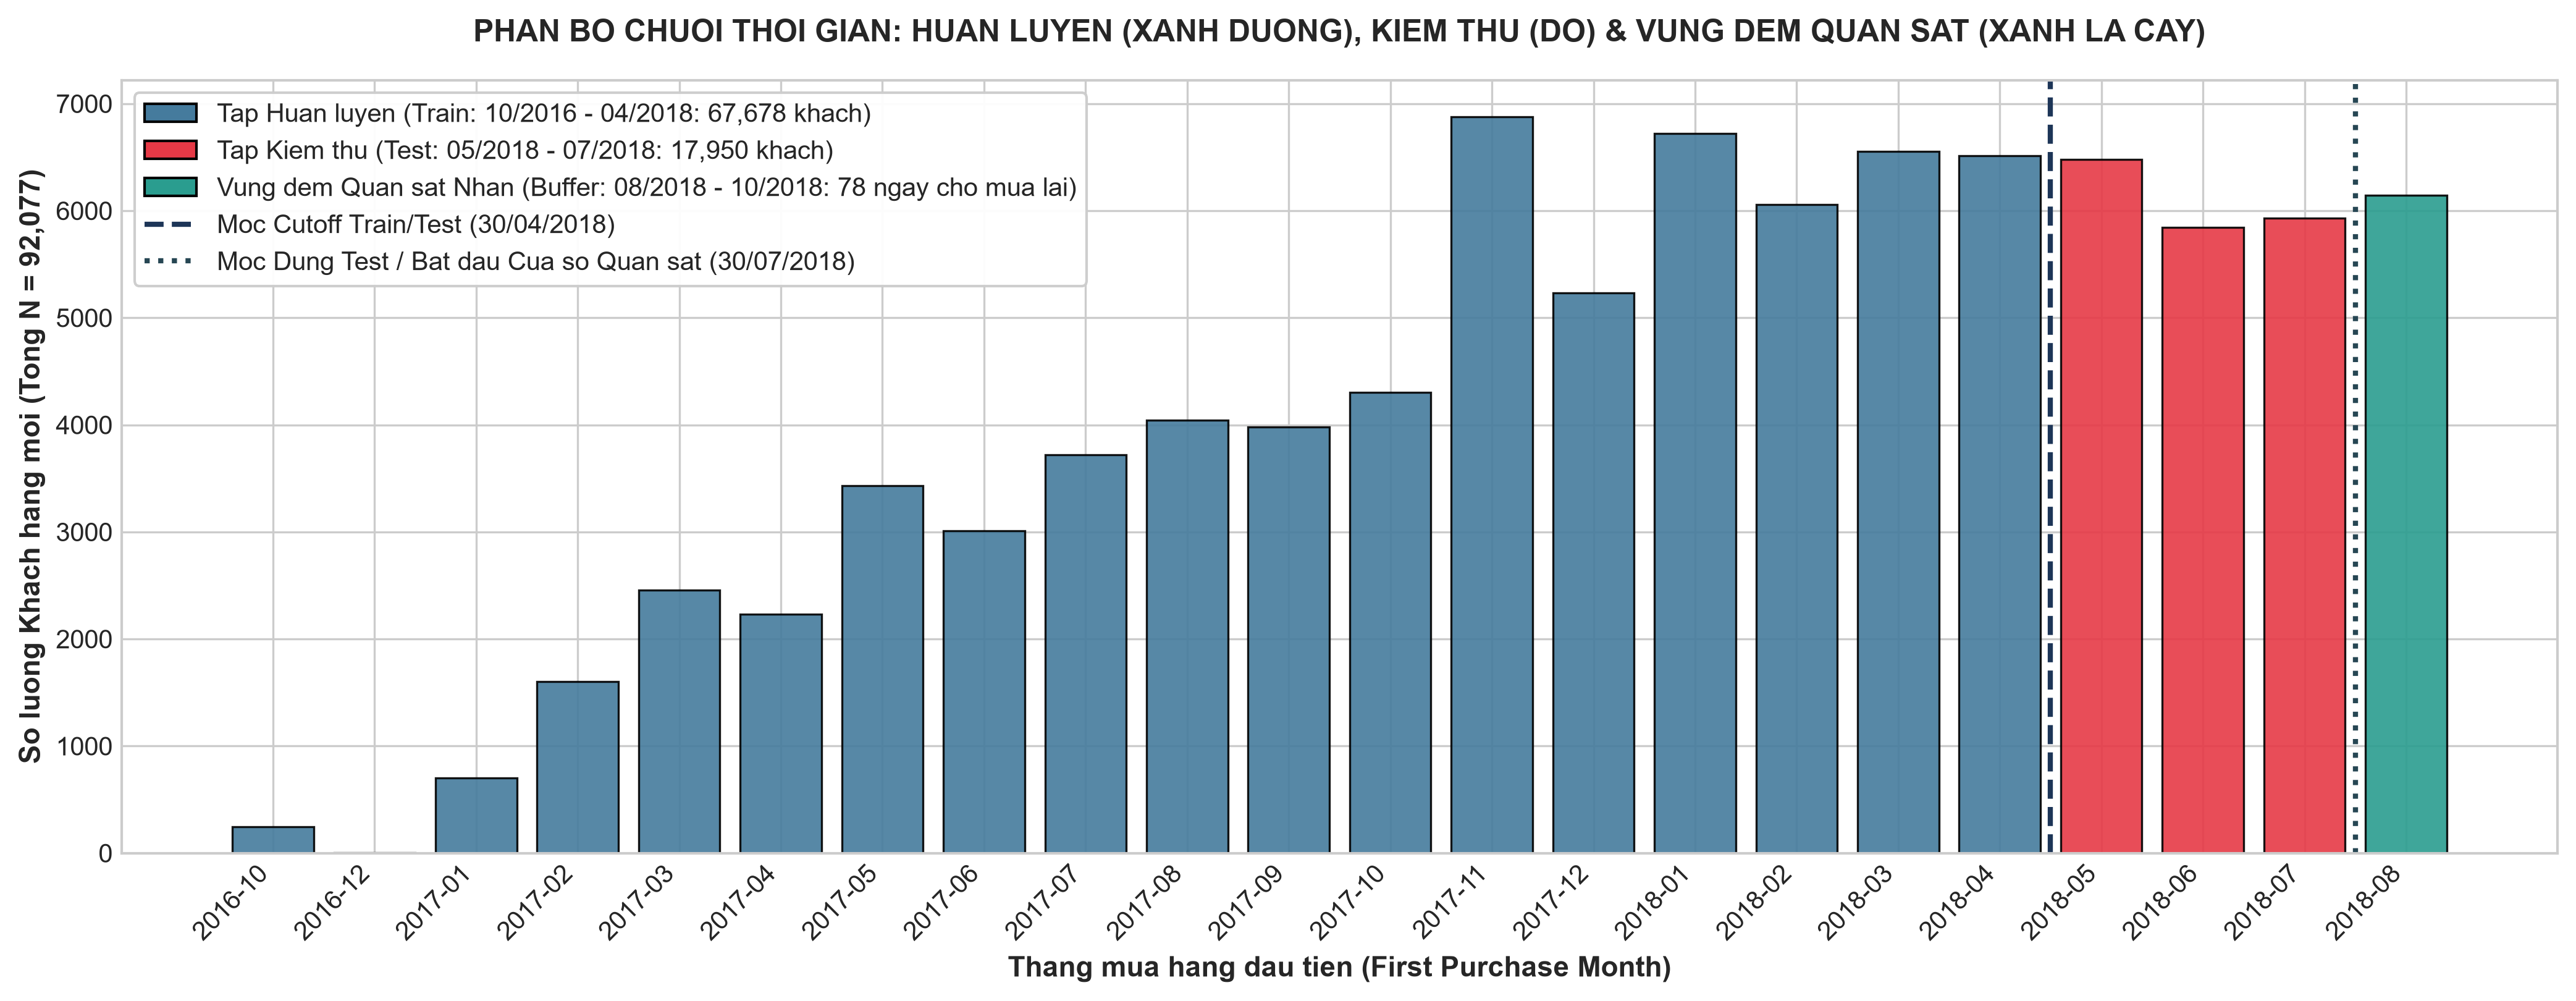


[OK] DA XUAT THANH CONG:
  - Toan bo tap du lieu phan chia vao thu muc: data\train_test/
  - Danh sach 33 dac trung chinh thuc vao: models\feature_columns.json


In [6]:
cutoff_date = pd.to_datetime('2018-04-30 23:59:59')
perf_window_end = pd.to_datetime('2018-07-30 23:59:59')
dataset_end_date = pd.to_datetime('2018-10-17 23:59:59')

train_mask = df_raw_pool['order_purchase_timestamp'] <= cutoff_date
test_mask = (df_raw_pool['order_purchase_timestamp'] > cutoff_date) & (df_raw_pool['order_purchase_timestamp'] <= perf_window_end)
buffer_mask = (df_raw_pool['order_purchase_timestamp'] > perf_window_end) & (df_raw_pool['order_purchase_timestamp'] <= dataset_end_date)

train_df = df_raw_pool[train_mask].copy()
test_df = df_raw_pool[test_mask].copy()
buffer_df = df_raw_pool[buffer_mask].copy()

X_train = train_df[final_selected_features]
y_train = train_df['is_retain']
X_test = test_df[final_selected_features]
y_test = test_df['is_retain']

print('=== KET QUA PHAN CHIA CHUOI THOI GIAN 3 GIAI DOAN (TEMPORAL SPLIT) ===')
print(f'1. Tap Huan luyen (Train):          {len(X_train):,} dong ({len(X_train)/len(df_raw_pool):.2%}) | Retain: {y_train.sum():,} ({y_train.mean():.2%})')
print(f'2. Tap Kiem thu (Test):             {len(X_test):,} dong ({len(X_test)/len(df_raw_pool):.2%}) | Retain: {y_test.sum():,} ({y_test.mean():.2%})')
print(f'3. Vung Dem Quan sat Nhan (Buffer): {len(buffer_df):,} dong ({len(buffer_df)/len(df_raw_pool):.2%}) | Danh quan sat nhan thuc te (78 ngay)')

# Ve bieu do phan bo chuoi thoi gian 3 mau
plt.figure(figsize=(14, 5.5))
df_raw_pool['purchase_month'] = df_raw_pool['order_purchase_timestamp'].dt.to_period('M')
monthly_counts = df_raw_pool['purchase_month'].value_counts().sort_index()

months_str = [str(m) for m in monthly_counts.index]

def get_bar_color(m_str):
    m_date = pd.to_datetime(f'{m_str}-01')
    if m_date <= cutoff_date:
        return '#457b9d' # Xanh duong - Train
    elif m_date <= perf_window_end:
        return '#e63946' # Do - Test
    else:
        return '#2a9d8f' # Xanh la cay - Performance Buffer

colors = [get_bar_color(m) for m in months_str]

bars = plt.bar(months_str, monthly_counts.values, color=colors, alpha=0.9, edgecolor='black', lw=0.8)

# Them cac duong moc thoi gian
train_end_idx = [i for i, m in enumerate(months_str) if pd.to_datetime(f'{m}-01') <= cutoff_date][-1]
test_end_idx = [i for i, m in enumerate(months_str) if pd.to_datetime(f'{m}-01') <= perf_window_end][-1]

plt.axvline(train_end_idx + 0.5, color='#1d3557', linestyle='--', lw=2)
plt.axvline(test_end_idx + 0.5, color='#264653', linestyle=':', lw=2)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#457b9d', edgecolor='black', label=f'Tap Huan luyen (Train: 10/2016 - 04/2018: {len(X_train):,} khach)'),
    Patch(facecolor='#e63946', edgecolor='black', label=f'Tap Kiem thu (Test: 05/2018 - 07/2018: {len(X_test):,} khach)'),
    Patch(facecolor='#2a9d8f', edgecolor='black', label=f'Vung dem Quan sat Nhan (Buffer: 08/2018 - 10/2018: 78 ngay cho mua lai)'),
    plt.Line2D([0], [0], color='#1d3557', linestyle='--', lw=2, label='Moc Cutoff Train/Test (30/04/2018)'),
    plt.Line2D([0], [0], color='#264653', linestyle=':', lw=2, label='Moc Dung Test / Bat dau Cua so Quan sat (30/07/2018)')
]

plt.title('PHAN BO CHUOI THOI GIAN: HUAN LUYEN (XANH DUONG), KIEM THU (DO) & VUNG DEM QUAN SAT (XANH LA CAY)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Thang mua hang dau tien (First Purchase Month)', fontsize=11, fontweight='bold')
plt.ylabel(f'So luong Khach hang moi (Tong N = {len(df_raw_pool):,})', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(handles=legend_elements, loc='upper left', frameon=True, framealpha=0.95, facecolor='white')
plt.tight_layout()
plt.savefig('time_split_distribution.png', dpi=300)
plt.show()

# Xuat du lieu sang data/train_test/ va feature_columns.json
out_dir = os.path.join('data', 'train_test')
models_dir = 'models'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

X_train.to_csv(os.path.join(out_dir, 'X_train.csv'), index=False)
y_train.to_csv(os.path.join(out_dir, 'y_train.csv'), index=False)
X_test.to_csv(os.path.join(out_dir, 'X_test.csv'), index=False)
y_test.to_csv(os.path.join(out_dir, 'y_test.csv'), index=False)
train_df.to_csv(os.path.join(out_dir, 'train_full.csv'), index=False)
test_df.to_csv(os.path.join(out_dir, 'test_full.csv'), index=False)

with open(os.path.join(models_dir, 'feature_columns.json'), 'w', encoding='utf-8') as f:
    json.dump(final_selected_features, f, indent=2, ensure_ascii=False)

print('\n[OK] DA XUAT THANH CONG:')
print(f'  - Toan bo tap du lieu phan chia vao thu muc: {out_dir}/')
print(f'  - Danh sach {len(final_selected_features)} dac trung chinh thuc vao: {os.path.join(models_dir, "feature_columns.json")}')
